In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import ShuffleSplit

import sys
sys.path.append("..")

from dataset_loader import TORGO, ParameterizedTORGO

In [2]:
torgo_param = ParameterizedTORGO("Torgo_selected.csv")
torgo_param_group1 = ParameterizedTORGO("Torgo_selected_group1.csv")
torgo_param_group2 = ParameterizedTORGO("Torgo_selected_group2.csv")

Loaded TORGO_CSV dataset with 14795 entries from Torgo_selected.csv.
Loaded TORGO_CSV dataset with 10748 entries from Torgo_selected_group1.csv.
Loaded TORGO_CSV dataset with 3768 entries from Torgo_selected_group2.csv.


In [3]:
subset = torgo_param.subset(
    #categories=['restricted_sentence', 'short_word', 'non_word', 'unrestricted_sentence', 'undefined'],
)
len(subset)

14795

In [4]:
subset_group1 = torgo_param_group1.subset(
    #categories=['restricted_sentence', 'short_word', 'non_word', 'unrestricted_sentence', 'undefined'],
)
len(subset_group1)

10748

In [5]:
subset_group2 = torgo_param_group2.subset(
    #categories=['restricted_sentence', 'short_word', 'non_word', 'unrestricted_sentence', 'undefined'],
)
len(subset_group2)

3768

## ALL

In [6]:
y = subset.df['label']
X = subset.df.drop('label',axis=1).copy()

In [7]:
X = X.dropna()
y = y[X.index]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

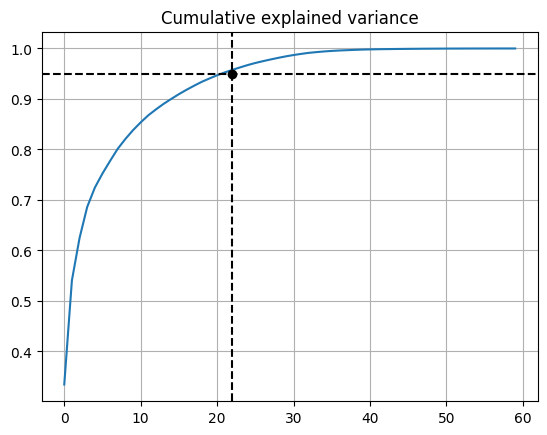

In [9]:
pca_temp = PCA(random_state=42)
X_pca_temp = pca_temp.fit_transform(X_scaled)
cumsum = np.cumsum(pca_temp.explained_variance_ratio_)
n_components_pca = np.argmax(cumsum >= 0.95) + 1

plt.plot(cumsum)
plt.axvline(n_components_pca, linestyle='--', color='k')
plt.axhline(0.95, linestyle='--', color='k')
plt.plot(n_components_pca, 0.95, "ko")
plt.title("Cumulative explained variance")
plt.grid()
plt.show()

In [10]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components_pca, random_state=42)),
    ('clf', SVC(kernel='rbf', random_state=42, probability=True))
])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
param_grid = {
    'clf__C': [1, 10, 100],
    'clf__gamma': [0.01, 0.1]
}

In [17]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Najlepsze parametry
print("Best parameters found: ", grid_search.best_params_)
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found:  {'clf__C': 10, 'clf__gamma': 0.1}


In [18]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

In [19]:
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2032
           1       0.96      0.95      0.95       927

    accuracy                           0.97      2959
   macro avg       0.97      0.97      0.97      2959
weighted avg       0.97      0.97      0.97      2959

Accuracy: 0.9716
Precision: 0.9587
Recall: 0.9504
F1 Score: 0.9545


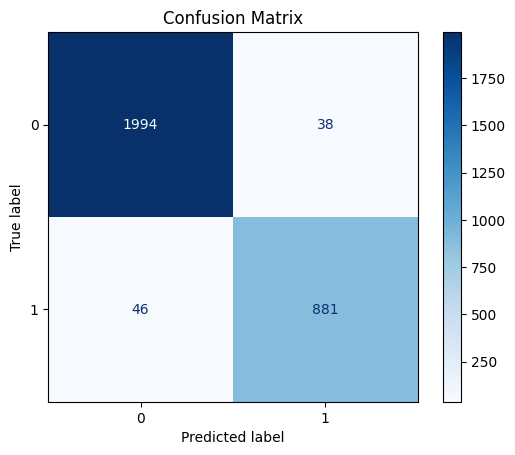

In [20]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

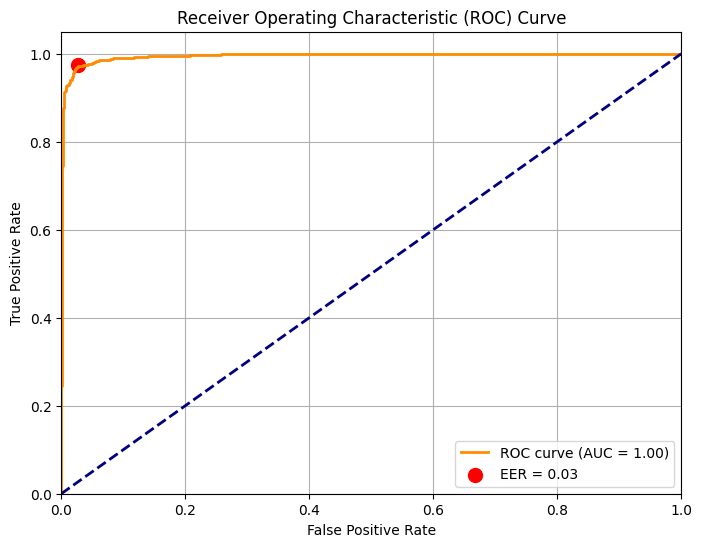


AUC: 0.9954
EER: 0.0266


In [24]:
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

eer_threshold = thresholds[np.argmin(np.abs(fpr - (1 - tpr)))]
eer = fpr[np.argmin(np.abs(fpr - (1 - tpr)))]

# Wykres ROC z AUC i EER
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(eer, 1 - eer, color='red', s=100, label=f'EER = {eer:.2f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

print(f"\nAUC: {roc_auc:.4f}")
print(f"EER: {eer:.4f}")

## Dwa zbiory

In [7]:
y1 = subset_group1.df['label']
X1 = subset_group1.df.drop('label',axis=1).copy()

In [8]:
y2 = subset_group2.df['label']
X2 = subset_group2.df.drop('label',axis=1).copy()

In [37]:
def process_and_evaluate(X,y, group_name):
    print(f"\n{'='*50}")
    print(f"Analiza dla {group_name}")
    print(f"{'='*50}")
    
    
    # Skalowanie i PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca_temp = PCA(random_state=42)
    X_pca_temp = pca_temp.fit_transform(X_scaled)
    cumsum = np.cumsum(pca_temp.explained_variance_ratio_)
    n_components_pca = np.argmax(cumsum >= 0.95) + 1
    
    # Wykres wyjaśnionej wariancji
    plt.figure(figsize=(10, 6))
    plt.plot(cumsum)
    plt.axvline(n_components_pca, linestyle='--', color='k')
    plt.axhline(0.95, linestyle='--', color='k')
    plt.plot(n_components_pca, 0.95, "ko")
    plt.title(f"Cumulative explained variance - {group_name}")
    plt.grid()
    plt.show()
    
    # Podział danych
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Definicja modelu z GridSearchCV
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components_pca, random_state=42)),
        ('clf', SVC(kernel='rbf', random_state=42, probability=True))
    ])
    
    # Parametry do przeszukania w GridSearch
    param_grid = {
        'clf__C': [1, 10, 100],
        'clf__gamma': [0.01, 0.1]
    }
    
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    
    # Najlepsze parametry
    print(f"\nBest parameters for {group_name}: ", grid_search.best_params_)
    best_model = grid_search.best_estimator_
    
    # Predykcje
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Raport klasyfikacji
    print(f"\nClassification Report - {group_name}:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
    
    # Macierz pomyłek
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {group_name}")
    plt.show()
    
    # Krzywa ROC, AUC i EER
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Obliczenie EER
    eer_threshold = thresholds[np.argmin(np.abs(fpr - (1 - tpr)))]
    eer = fpr[np.argmin(np.abs(fpr - (1 - tpr)))]
    
    # Wykres ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(eer, 1 - eer, color='red', s=100, label=f'EER = {eer:.2f}')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {group_name}')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()
    
    print(f"\nAUC for {group_name}: {roc_auc:.4f}")
    print(f"EER for {group_name}: {eer:.4f}")
    
    return best_model


Analiza dla Group 1


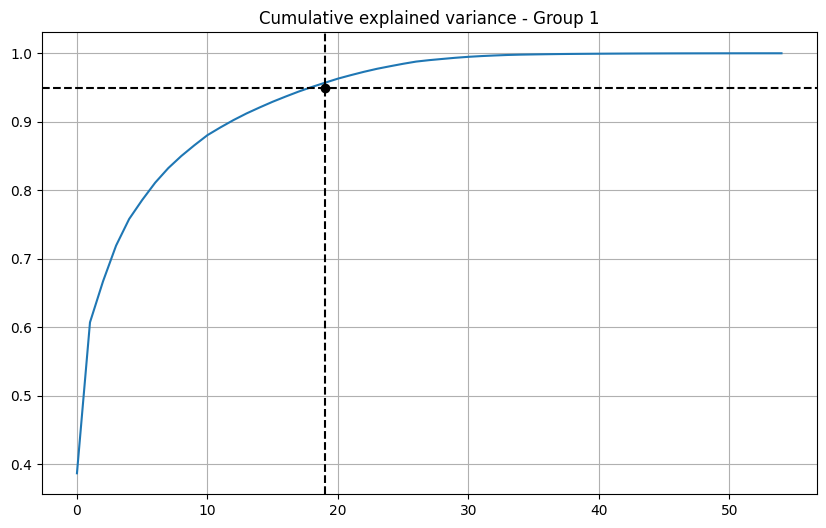

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best parameters for Group 1:  {'clf__C': 10, 'clf__gamma': 0.1}

Classification Report - Group 1:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1483
           1       0.96      0.95      0.96       667

    accuracy                           0.97      2150
   macro avg       0.97      0.97      0.97      2150
weighted avg       0.97      0.97      0.97      2150

Accuracy: 0.9735
Precision: 0.9607
Recall: 0.9535
F1 Score: 0.9571


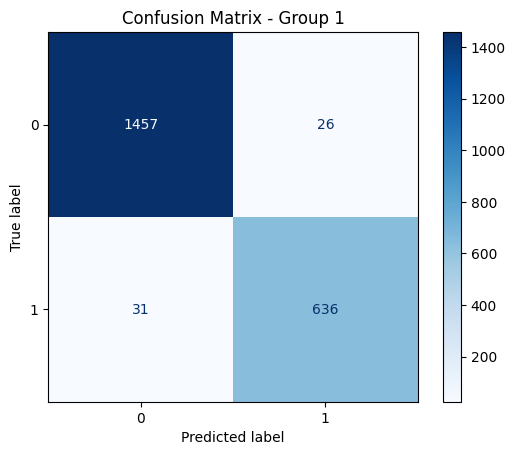

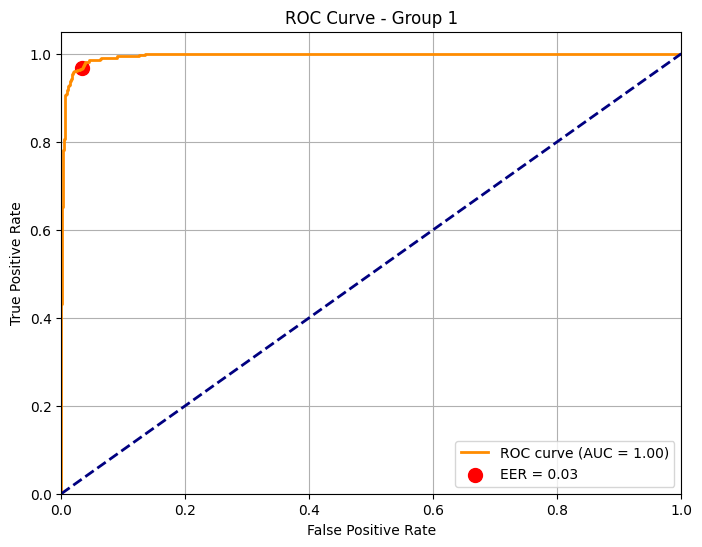


AUC for Group 1: 0.9956
EER for Group 1: 0.0330

Analiza dla Group 2


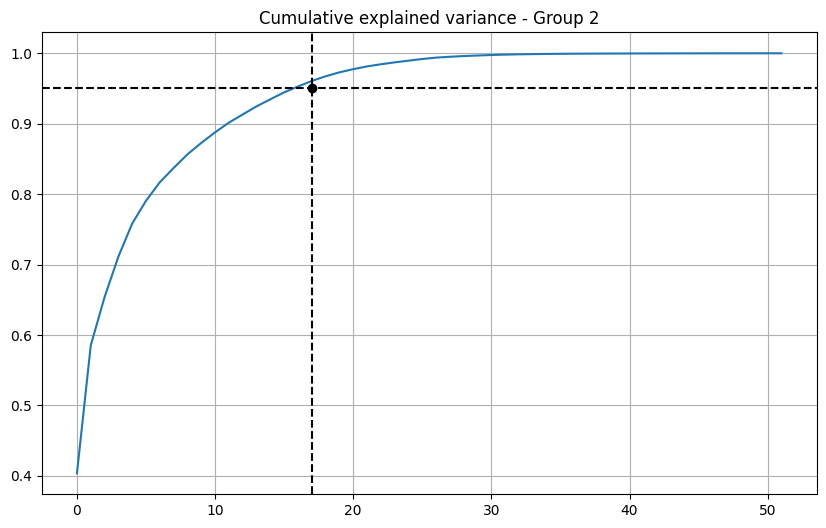

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best parameters for Group 2:  {'clf__C': 1, 'clf__gamma': 0.1}

Classification Report - Group 2:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       532
           1       0.98      0.98      0.98       222

    accuracy                           0.99       754
   macro avg       0.99      0.98      0.99       754
weighted avg       0.99      0.99      0.99       754

Accuracy: 0.9881
Precision: 0.9819
Recall: 0.9775
F1 Score: 0.9797


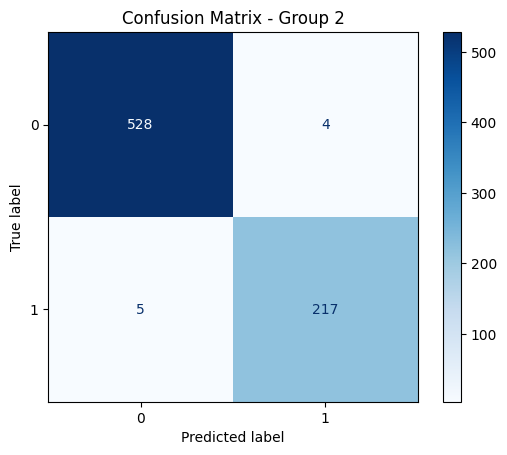

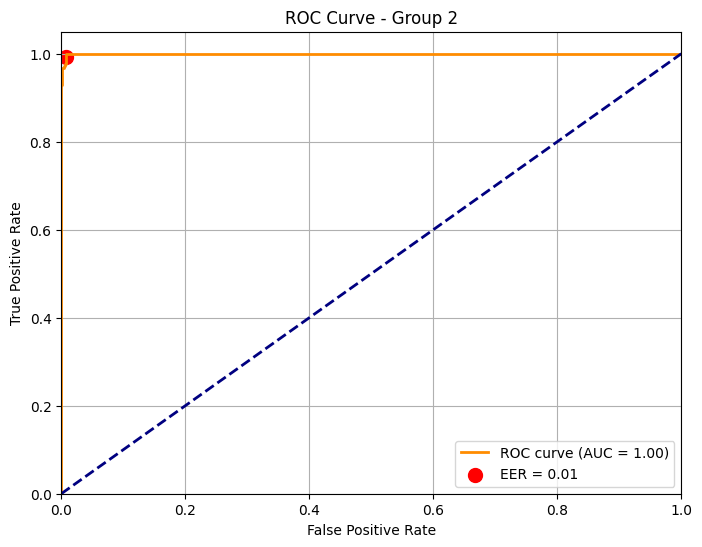


AUC for Group 2: 0.9997
EER for Group 2: 0.0075


In [38]:
model_group1 = process_and_evaluate(X1, y1, "Group 1")
model_group2 = process_and_evaluate(X2, y2, "Group 2")

## 5x2cv

In [13]:
def create_model(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca_temp = PCA(random_state=42)
    X_pca_temp = pca_temp.fit_transform(X_scaled)
    cumsum = np.cumsum(pca_temp.explained_variance_ratio_)
    n_components_pca = np.argmax(cumsum >= 0.95) + 1
    
    # Wykres wyjaśnionej wariancji
    plt.figure(figsize=(10, 6))
    plt.plot(cumsum)
    plt.axvline(n_components_pca, linestyle='--', color='k')
    plt.axhline(0.95, linestyle='--', color='k')
    plt.plot(n_components_pca, 0.95, "ko")
    plt.title(f"Cumulative explained variance")
    plt.grid()
    plt.show()
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('clf', SVC(kernel='rbf', probability=True, random_state=42))
    ])
    
    param_grid = {
        'clf__C': [1, 10, 100],
        'clf__gamma': [0.01,0.1, 1]
    }
    
    return GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

In [12]:
def run_5x2cv(X, y, random_state=42):
    splitter = ShuffleSplit(n_splits=5, test_size=0.5, random_state=random_state)
    model = create_model(X)

    all_scores = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X), start=1):
        # First split
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        score1 = accuracy_score(y_test, preds)

        # Second split (train/test reversed)
        model.fit(X_test, y_test)
        preds = model.predict(X_train)
        score2 = accuracy_score(y_train, preds)

        all_scores.append((score1, score2))
        print(f"Fold {fold}: Acc1 = {score1:.3f}, Acc2 = {score2:.3f}")

    all_scores = np.array(all_scores)
    mean_score = np.mean(all_scores)
    var_score = np.var(all_scores)
    print(f"\nMean 5x2CV Accuracy: {mean_score:.3f}")
    print(f"\Variance of 5x2CV Accuracy: {var_score:.3f}")
    return all_scores

<>:28: SyntaxWarning: invalid escape sequence '\V'
<>:28: SyntaxWarning: invalid escape sequence '\V'
C:\Users\poreb\AppData\Local\Temp\ipykernel_18628\1992891049.py:28: SyntaxWarning: invalid escape sequence '\V'
  print(f"\Variance of 5x2CV Accuracy: {var_score:.3f}")


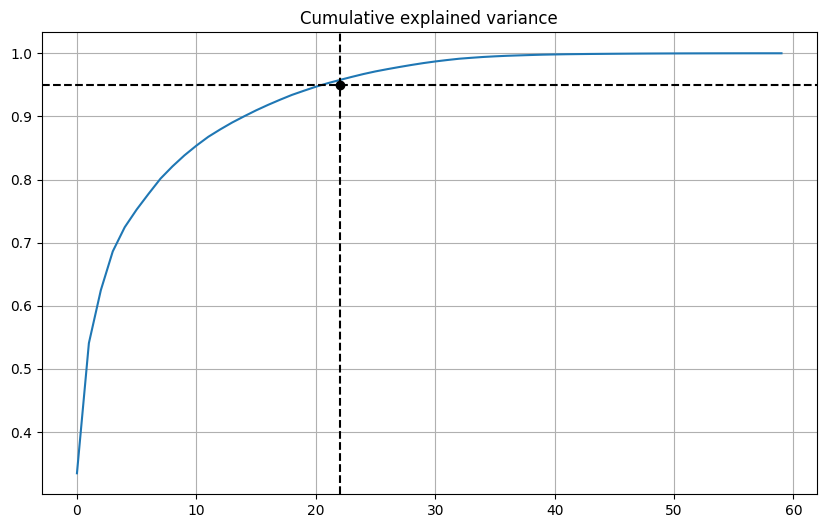

Fold 1: Acc1 = 0.971, Acc2 = 0.969
Fold 2: Acc1 = 0.972, Acc2 = 0.971
Fold 3: Acc1 = 0.974, Acc2 = 0.971
Fold 4: Acc1 = 0.971, Acc2 = 0.974
Fold 5: Acc1 = 0.970, Acc2 = 0.969

Mean 5x2CV Accuracy: 0.971
\Variance of 5x2CV Accuracy: 0.000
[[0.97120843 0.96863593]
 [0.97161395 0.97133973]
 [0.97404704 0.97079897]
 [0.97134361 0.97377315]
 [0.97012706 0.96931188]]


In [18]:
all_results = run_5x2cv(X, y)
print(all_results)

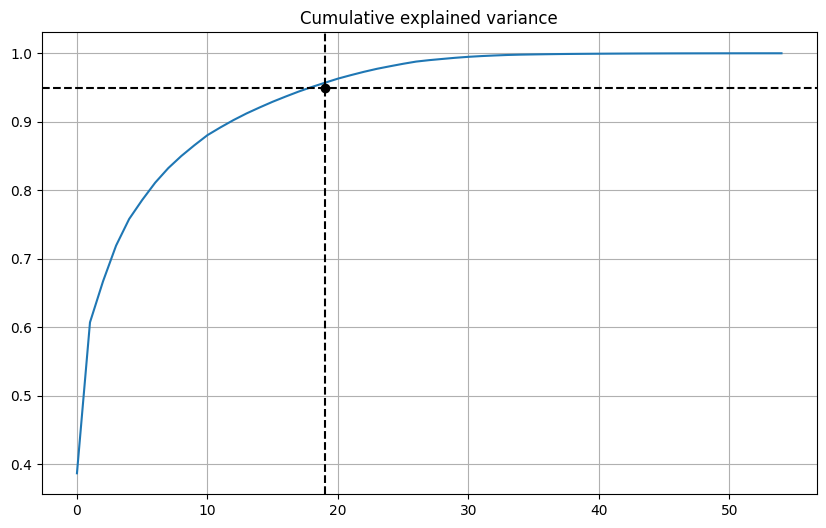

Fold 1: Acc1 = 0.964, Acc2 = 0.966
Fold 2: Acc1 = 0.967, Acc2 = 0.962
Fold 3: Acc1 = 0.964, Acc2 = 0.970
Fold 4: Acc1 = 0.972, Acc2 = 0.965
Fold 5: Acc1 = 0.964, Acc2 = 0.968

Mean 5x2CV Accuracy: 0.966
\Variance of 5x2CV Accuracy: 0.000
[[0.96427242 0.96594715]
 [0.9665054  0.96222553]
 [0.96371418 0.97022702]
 [0.97190175 0.96520283]
 [0.96390026 0.96818013]]


In [17]:
g1_results = run_5x2cv(X1, y1)
print(g1_results)

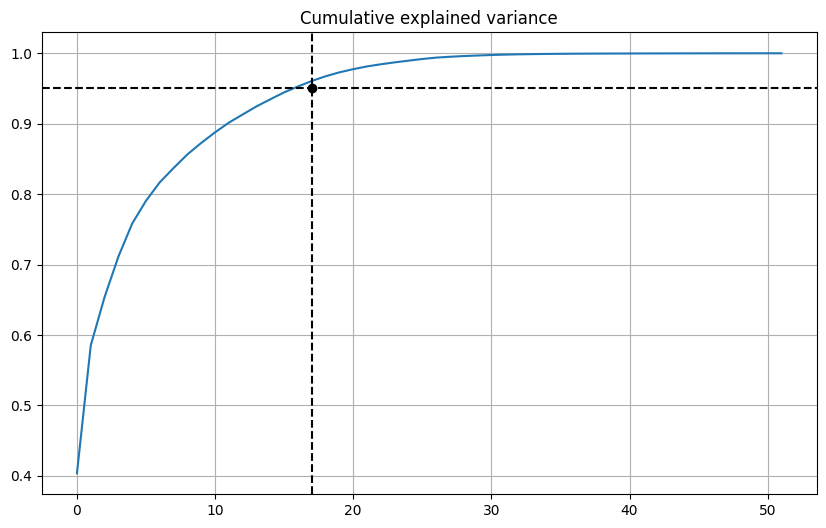

Fold 1: Acc1 = 0.980, Acc2 = 0.988
Fold 2: Acc1 = 0.979, Acc2 = 0.986
Fold 3: Acc1 = 0.985, Acc2 = 0.981
Fold 4: Acc1 = 0.987, Acc2 = 0.982
Fold 5: Acc1 = 0.987, Acc2 = 0.980

Mean 5x2CV Accuracy: 0.984
\Variance of 5x2CV Accuracy: 0.000
[[0.98036093 0.98832272]
 [0.97929936 0.98566879]
 [0.985138   0.98089172]
 [0.98673036 0.98248408]
 [0.98673036 0.98036093]]


In [16]:
g2_results = run_5x2cv(X2, y2)
print(g2_results)